# **SETUP**

---

In [3]:
import os
import random
from typing import List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import accuracy_score, confusion_matrix, jaccard_score
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Dataset, random_split
from torchmetrics import Accuracy, ConfusionMatrix, JaccardIndex

from tqdm import tqdm

W0906 10:20:48.774000 13036 torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


# **DATASET**

---

In [4]:
class AI4MARSDataset(Dataset):
    def __init__(self, images_path: str, masks_path: str, dataset_size: int = 500):
        self.images_path = images_path
        self.masks_path = masks_path
        self.dataset_size = dataset_size
        
        images = set(os.listdir(images_path))
        self.masks = [mask for mask in os.listdir(masks_path) if mask[:-4] + ".JPG" in images][:dataset_size]

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        mask_name = self.masks[idx]

        image_path = os.path.join(self.images_path, mask_name[:-4] + ".JPG")
        image = cv2.imread(image_path)
        image = cv2.resize(image, (224, 224))
        image = np.asarray(image, dtype=np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))  
        image = torch.from_numpy(image)

        mask_path = os.path.join(self.masks_path, mask_name)
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
        mask = np.array(mask, dtype=np.uint8)
        mask[mask == 255] = 4
        mask = torch.from_numpy(mask)
        mask = mask.long()

        return image, mask

class AI4MARSDataModule(pl.LightningDataModule):
    def __init__(self, images_path: str, masks_path: str, dataset_size: int = 5000, batch_size: int = 32, num_workers: int = 4):
        super().__init__()
        self.images_path = images_path
        self.masks_path = masks_path
        self.dataset_size = dataset_size
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.dataset = AI4MARSDataset(self.images_path, self.masks_path, self.dataset_size)

    def train_dataloader(self):
        return DataLoader(self.dataset, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True, pin_memory=True)

# **MODEL**

---

In [5]:
class ImageSegmentationModel(pl.LightningModule):
    def __init__(self, num_classes: int = 5, learning_rate: float = 1e-4):
        super().__init__()

        self.save_hyperparameters()
        self.learning_rate = learning_rate
        self.num_classes = num_classes

        self.model_weights = torchvision.models.segmentation.FCN_ResNet50_Weights.DEFAULT
        self.model = torchvision.models.segmentation.fcn_resnet50(weights=self.model_weights)
        self.model.classifier[-1] = nn.Conv2d(512, num_classes, kernel_size=(1, 1), stride=(1, 1))

        self.loss = nn.CrossEntropyLoss()
        self.confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=num_classes)
        self.accuracy = Accuracy(task='multiclass', num_classes=num_classes)
        self.iou = JaccardIndex(task='multiclass', num_classes=num_classes)

    def forward(self, x):
        return self.model(x)['out']

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss(preds, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss(preds, y)
        preds = torch.argmax(preds, dim=1)

        # Log metrics
        self.log('val_loss', loss, on_step=True, on_epoch=True)
        self.log('val_acc', self.accuracy(preds, y), on_step=True, on_epoch=True)
        self.log('val_iou', self.iou(preds, y), on_step=True, on_epoch=True)

# **TRAINING**

---

In [6]:
def train_single_run(data_module: AI4MARSDataModule, epochs: int = 100):

    # Split dataset into training and validation sets
    dataset_size = len(data_module.dataset)

    train_size = int(dataset_size * 0.8)
    val_size = dataset_size - train_size

    train_dataset, val_dataset = random_split(
        data_module.dataset,
        [train_size, val_size]
    )

    print("Total samples :", dataset_size)
    print("Training samples:", train_size)
    print("Validation samples:", val_size)

    # Set up data loaders

    num_workers = 0

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=data_module.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=data_module.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # Initialize model

    model = ImageSegmentationModel()

    # Select gpu


    if torch.cuda.is_available():

        accelerator = "gpu"
        devices = 1

        print("\nUsing GPU:")
        print(torch.cuda.get_device_name(0))

    else:

        accelerator = "cpu"
        devices = 1

        print("\nCUDA GPU not available.")
        print("Using CPU.")

    # Set up Lightning Trainer


    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator=accelerator,
        devices=devices,
        log_every_n_steps=50
    )


    # TRAINING

    print("\n==============================")
    print("Starting training...")
    print("Epochs:", epochs)
    print("Workers:", num_workers)
    print("==============================\n")

    trainer.fit(
        model,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader
    )


    # Training completed


    print("\n==============================")
    print("Training completed!")
    print("==============================")

    print("Epochs completed:", trainer.current_epoch)
    print("Global steps:", trainer.global_step)

    return model, trainer

# **EXECUTION**

---

In [25]:
# local path
IMAGES_PATH = r"C:\Users\manus\archive\ai4mars-dataset-merged-0.1\msl\images\edr"
MASK_PATH_TRAIN = r"C:\Users\manus\archive\ai4mars-dataset-merged-0.1\msl\labels\train"

MASK_PATH_TEST = r"C:\Users\manus\archive\ai4mars-dataset-merged-0.1\msl\labels\test\masked-gold-min1-100agree"

# Hyperparameters
DATASET_SIZE = 5120
BATCH_SIZE = 32
EPOCHS = 10

In [26]:
# Load dataset
rock_data = AI4MARSDataModule(
    IMAGES_PATH,
    MASK_PATH_TRAIN,
    dataset_size=DATASET_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0
)

rock_data.setup()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [28]:
model, trainer = train_single_run(
    rock_data,
    epochs=EPOCHS
)

Total samples : 5120
Training samples: 4096
Validation samples: 1024


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                      | Params | Mode  | FLOPs
-------------------------------------------------------------------------------
0 | model            | FCN                       | 35.3 M | train | 0    
1 | loss             | CrossEntropyLoss          | 0      | train | 0    
2 | confusion_matrix | MulticlassConfusionMatrix | 0      | train | 0    
3 | accuracy         | MulticlassAccuracy        | 0      | train 


Using GPU:
NVIDIA GeForce RTX 4050 Laptop GPU

Starting training...
Epochs: 10
Workers: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\manus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\manus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


C:\Users\manus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 128/128 [37:48<00:00,  0.06it/s, v_num=13]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 128/128 [37:49<00:00,  0.06it/s, v_num=13]

Training completed!
Epochs completed: 10
Global steps: 1280


# **DEMONSTRATION**

---

In [29]:
# Preprocess images
def preprocess_image(image_path: str, return_tensor: bool = False):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))
    image_normalized = np.asarray(image, dtype=np.float32) / 255.0
    
    if return_tensor:
        image_normalized = np.transpose(image_normalized, (2, 0, 1))
        image_tensor = torch.from_numpy(image_normalized).unsqueeze(0)
        return image, image_tensor
    
    return image

# Preprocess masks
def preprocess_mask(mask_path: str):
    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    mask[mask == 255] = 4
    return mask

# Find an image in the test set
def display_segmentation(index):
    mask_files = [filename for filename in os.listdir(MASK_PATH_TEST) if filename.endswith("_merged.png")]
    test_image_name = mask_files[index][:-11] + ".JPG"

    # Load the test image
    test_image_path = os.path.join(IMAGES_PATH, test_image_name)
    test_image, test_image_tensor = preprocess_image(test_image_path, return_tensor=True)
    test_image_tensor = test_image_tensor.to(device)

    # Perform prediction
    with torch.no_grad():
        prediction = model(test_image_tensor)
        predicted_mask = torch.argmax(prediction, dim=1).squeeze().cpu().numpy()

    # Load the ground truth segmentation
    ground_truth_mask_path = os.path.join(MASK_PATH_TEST, test_image_name[:-4] + "_merged.png")
    ground_truth_mask = preprocess_mask(ground_truth_mask_path)

    return test_image, ground_truth_mask, predicted_mask

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using the trained model directly (no .pth file)


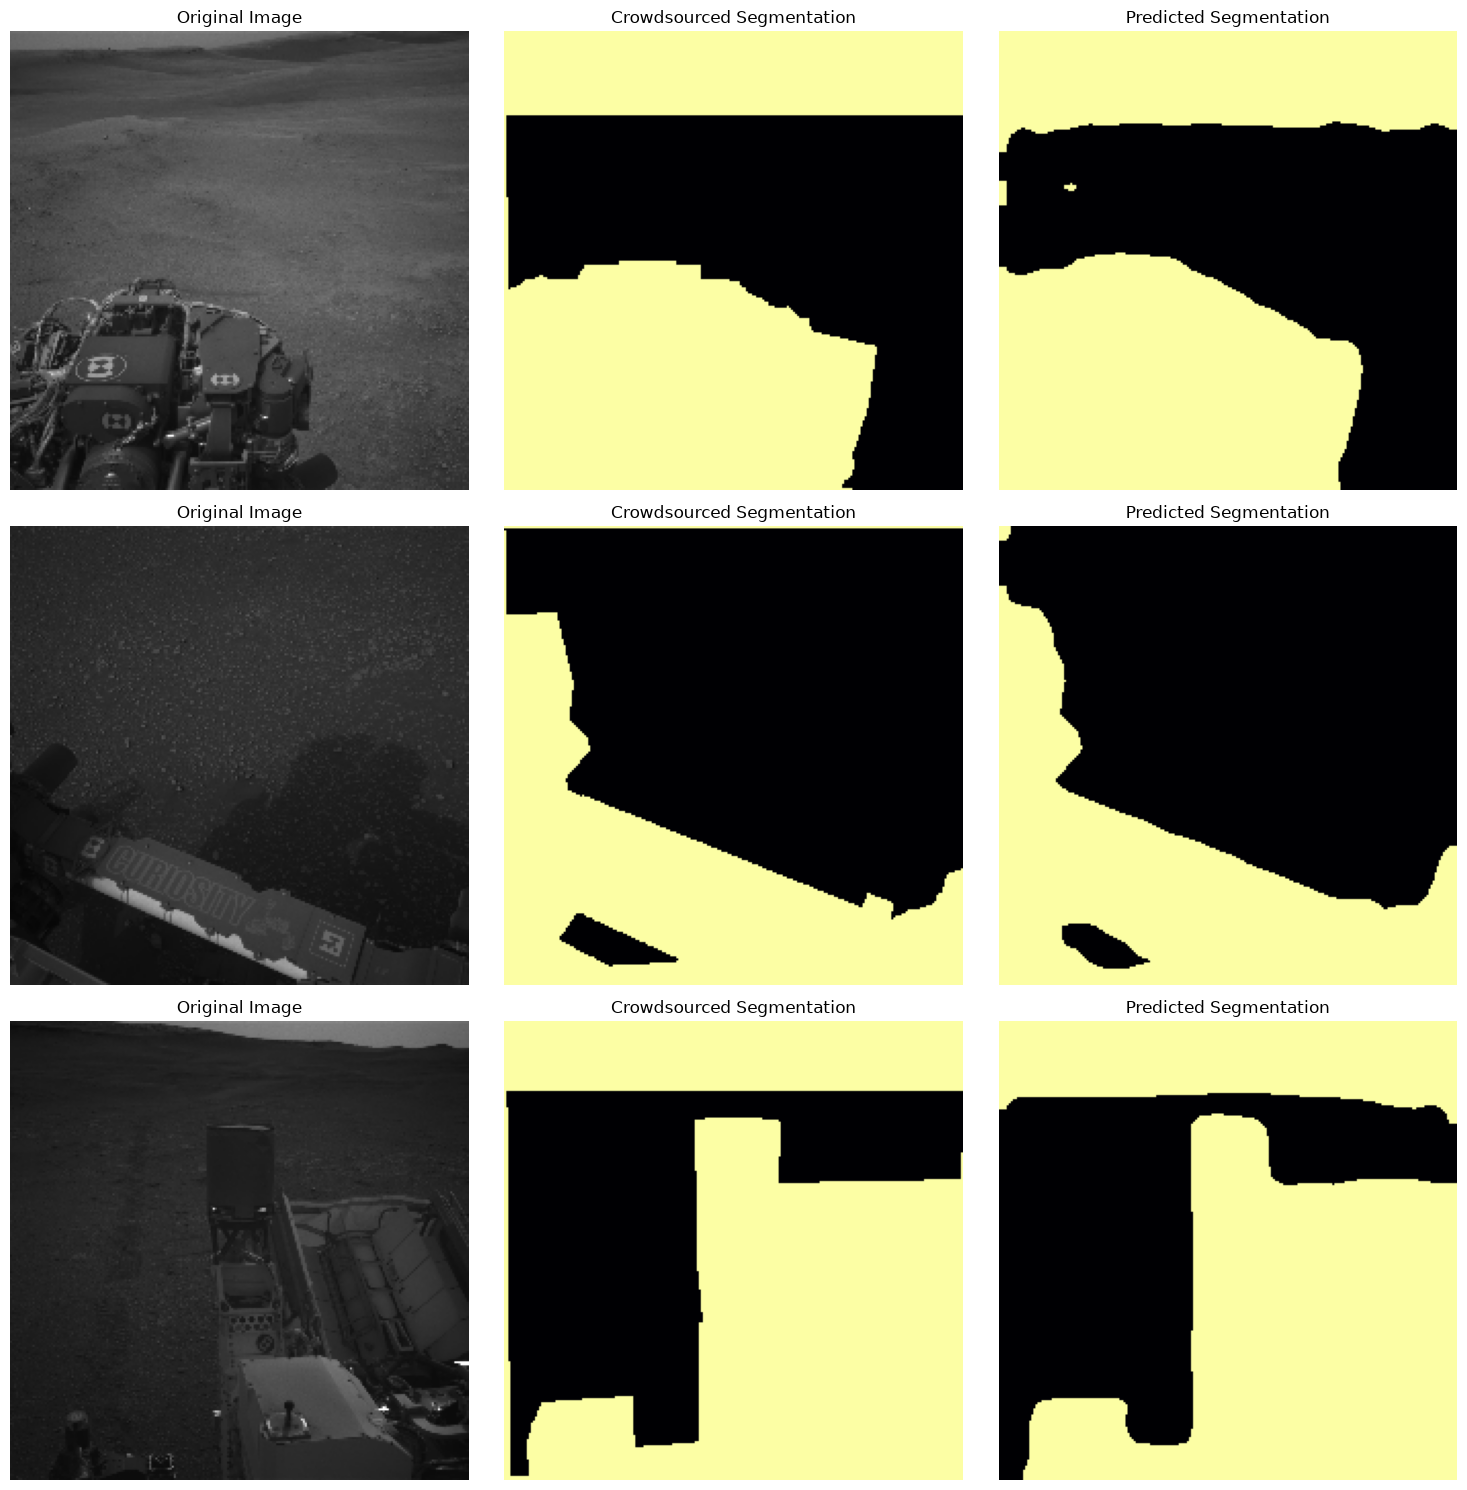

In [30]:
# Choose device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



model = model.to(device)
model.eval()

print("Using the trained model directly (no .pth file)")


# Choose indices
indices = [11, 12, 16]

segmentations = [
    display_segmentation(index)
    for index in indices
]


# Plots
fig, axes = plt.subplots(
    len(indices),
    3,
    figsize=(15, 15)
)

for i, (test_image, ground_truth_mask, predicted_mask) in enumerate(segmentations):

    # Original image
    axes[i, 0].imshow(
        cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    )
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        ground_truth_mask,
        cmap="inferno"
    )
    axes[i, 1].set_title("Crowdsourced Segmentation")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(
        predicted_mask,
        cmap="inferno"
    )
    axes[i, 2].set_title("Predicted Segmentation")
    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

# **EVALUATION**

---

In [34]:
class TestDataset(Dataset):
    def __init__(self, images_path: str, masks_path: str):
        self.images_path = images_path
        self.masks_path = masks_path
        self.mask_files = [mask for mask in os.listdir(masks_path) if mask.endswith("_merged.png")]

    def __len__(self):
        return len(self.mask_files)

    def __getitem__(self, idx):
        mask_name = self.mask_files[idx]
        image_name = mask_name[:-11] + ".JPG"

        image_path = os.path.join(self.images_path, image_name)
        _, image_tensor = preprocess_image(image_path, return_tensor=True)

        mask_path = os.path.join(self.masks_path, mask_name)
        mask = preprocess_mask(mask_path)

        # Remove the extra dimension
        image_tensor = image_tensor.squeeze(0)

        return image_tensor, mask

In [35]:
def evaluate_test_set(model, images_path, masks_path, batch_size=32, num_workers=2, device='cuda'):
    
    # Load dataloaders
    test_dataset = TestDataset(images_path, masks_path)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)

    # Initialize arrays for storing ground truth and predictions
    ground_truths = []
    predictions = []

    for batch_images, batch_masks in tqdm(test_dataloader):
        # Move the images to the GPU
        batch_images = batch_images.to(device)

        # Perform prediction
        with torch.no_grad():
            batch_prediction = model(batch_images)
            batch_predicted_masks = torch.argmax(batch_prediction, dim=1).cpu().numpy()

        # Flatten and append the ground truth and predictions
        ground_truths.extend([mask.flatten() for mask in batch_masks])
        predictions.extend([mask.flatten() for mask in batch_predicted_masks])

    # Compute accuracy
    accuracy = accuracy_score(np.concatenate(ground_truths), np.concatenate(predictions))

    # Compute IoU (Jaccard score)
    iou = jaccard_score(np.concatenate(ground_truths), np.concatenate(predictions), average="weighted")

    # Compute confusion matrix
    cm = confusion_matrix(np.concatenate(ground_truths), np.concatenate(predictions))
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    return accuracy, iou, cm_normalized

Number of test masks: 322
Matching image/mask pairs: 322
Total pixels evaluated: 21102592
Accuracy: 0.4708
IoU: 0.4031


C:\Users\manus\AppData\Local\Temp\ipykernel_13036\3343701689.py:204: RuntimeWarning: invalid value encountered in divide
  cm.astype(float) /


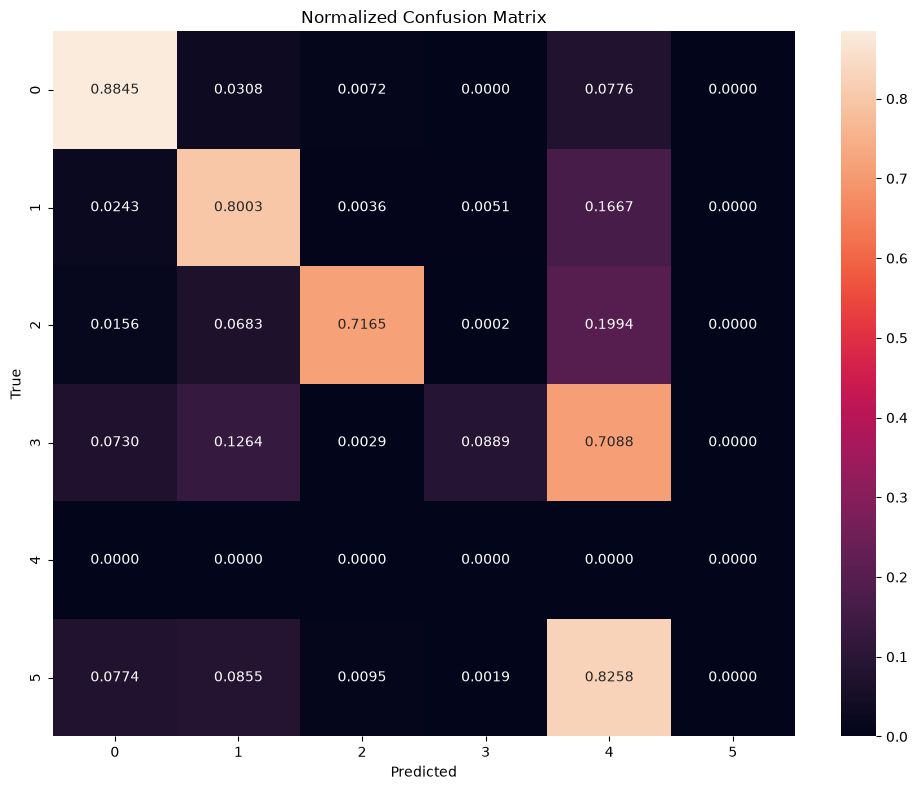

In [40]:
accuracy, iou, cm_normalized = evaluate_test_set(
    model,
    IMAGES_PATH,
    MASK_PATH_TEST,
    device=device
)

print(f"Accuracy: {accuracy:.4f}")
print(f"IoU: {iou:.4f}")

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".4f"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

# PROBABILITY DATAFRAME

In [107]:
probability_df = pd.DataFrame({
    "image_index": [random_index],
    "soil_prob": [soil_prob],
    "bedrock_prob": [bedrock_prob],
    "sand_prob": [sand_prob],
    "rock_prob": [rock_prob]
})

Random test image indices:
[40]
Processing image 1/1 (test index: 40)

PROBABILITY DATAFRAME



,image_index,soil_prob,bedrock_prob,sand_prob,rock_prob
0,40,0.704595,0.000483,0.000619,0.000541



DISPLAYING 1 RANDOM TEST IMAGES



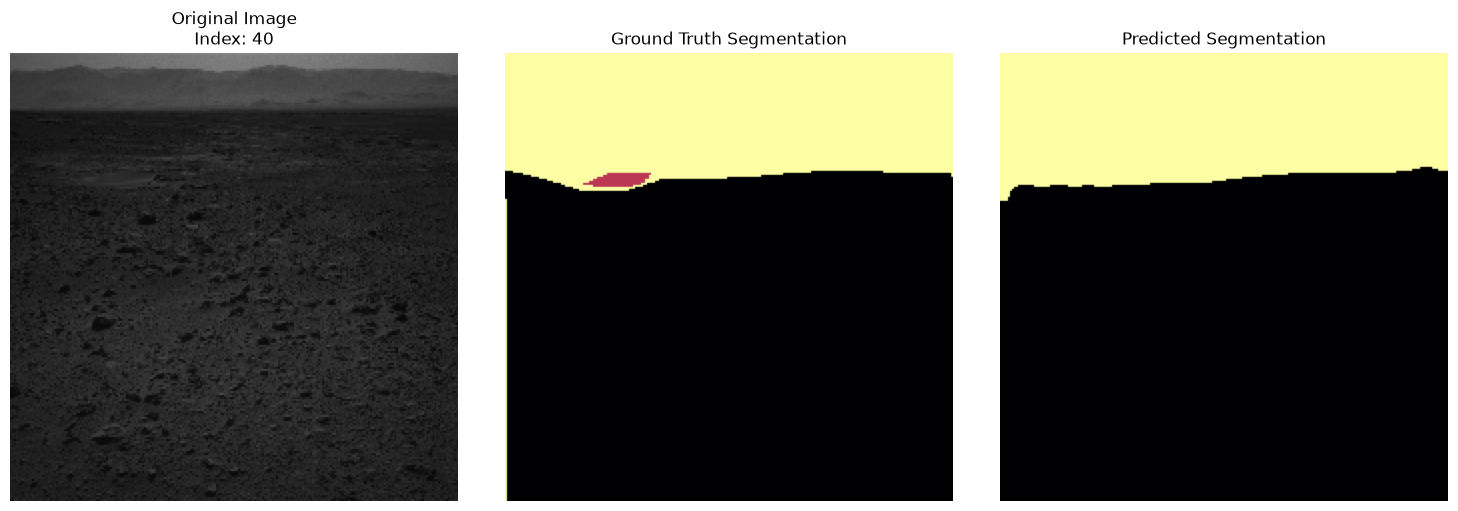

In [114]:
import random
import matplotlib.pyplot as plt
import cv2
import torch
import pandas as pd
import numpy as np

NUM_RANDOM_IMAGES = 1    #no. of random images
TOTAL_TEST_IMAGES = 322


if NUM_RANDOM_IMAGES > TOTAL_TEST_IMAGES:
    raise ValueError(
        f"NUM_RANDOM_IMAGES cannot be greater than {TOTAL_TEST_IMAGES}"
    )


random_indices = random.sample(
    range(TOTAL_TEST_IMAGES),
    NUM_RANDOM_IMAGES
)

print("Random test image indices:")
print(random_indices)


model.eval()
results = []
images_for_display = []


for i, random_index in enumerate(random_indices):

    print(
        f"Processing image {i+1}/{NUM_RANDOM_IMAGES} "
        f"(test index: {random_index})"
    )
    # Get image, ground truth and prediction

    test_image, ground_truth_mask, predicted_mask = (
        display_segmentation(random_index)
    )
    image_rgb = cv2.cvtColor(
        test_image,
        cv2.COLOR_BGR2RGB
    )

    image_tensor = (
        torch.from_numpy(image_rgb)
        .float() / 255.0
    )

    image_tensor = image_tensor.permute(2, 0, 1)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():

        output = model(input_tensor)

        if isinstance(output, dict):
            output = output["out"]

        probabilities = torch.softmax(
            output,
            dim=1
        )
        
    # Average probability for each class
    probabilities = probabilities.squeeze(0)

    class_probabilities = probabilities.mean(
        dim=(1, 2)
    )

    class_probabilities = (
        class_probabilities
        .cpu()
        .numpy()
    )

    # Extract probabilities

    soil_prob = float(class_probabilities[0])
    bedrock_prob = float(class_probabilities[1])
    sand_prob = float(class_probabilities[2])
    rock_prob = float(class_probabilities[3])
    
    results.append({
        "image_index": random_index,
        "soil_prob": soil_prob,
        "bedrock_prob": bedrock_prob,
        "sand_prob": sand_prob,
        "rock_prob": rock_prob
    })

    images_for_display.append({
        "index": random_index,
        "image": test_image,
        "ground_truth": ground_truth_mask,
        "prediction": predicted_mask
    })

probability_df = pd.DataFrame(results)


print("\n==========================================")
print("PROBABILITY DATAFRAME")
print("==========================================\n")

display(probability_df)

# DISPLAY TEST IMAGES


print("\n==========================================")
print(f"DISPLAYING {NUM_RANDOM_IMAGES} RANDOM TEST IMAGES")
print("==========================================\n")


for item in images_for_display:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    # Original image
    axes[0].imshow(
        cv2.cvtColor(
            item["image"],
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        f"Original Image\nIndex: {item['index']}"
    )

    axes[0].axis("off")


    # Ground truth
    axes[1].imshow(
        item["ground_truth"],
        cmap="inferno"
    )

    axes[1].set_title(
        "Ground Truth Segmentation"
    )

    axes[1].axis("off")


    # Prediction
    axes[2].imshow(
        item["prediction"],
        cmap="inferno"
    )

    axes[2].set_title(
        "Predicted Segmentation"
    )

    axes[2].axis("off")


    plt.tight_layout()
    plt.show()

In [113]:
probability_df

,image_index,soil_prob,bedrock_prob,sand_prob,rock_prob
0,48,0.386886,0.002276,0.000534,0.000623
